In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1.CSV file oxuyun.

In [3]:
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
#2.Orta, Median və Mod: BMI üçün orta, median və mod tapın; hansı göstərici daha düzgün nəticəni əks etdirir?  

In [5]:
import scipy as stat
print(f'BMI score mean: {df['BMI'].mean()}')
print(f'BMI score median: {df['BMI'].median()}')
print(f'BMI score mode: {df['BMI'].mode()[0]}')

BMI score mean: 28.382363607694735
BMI score median: 27.0
BMI score mode: 27.0


In [6]:
#3.Dispersiya və Standart Sapma: Age dəyişəninin dispersiyası və standart sapmasını hesablayın; yaşlar necə paylanıb?  

In [7]:
print(f'Age variance: {df['Age'].var()}')
print(f'Age std: {df['Age'].std()}')

Age variance: 9.328262460489782
Age std: 3.054220434168068


In [8]:
#4.Nisbi tezlik: Smoker dəyişənində neçə faiz insan siqaret çəkir?

In [9]:
print(f'Smoker percentage: {(len(df['Smoker'][df['Smoker'] == 1]) / len(df['Smoker'])) * 100}%')

Smoker percentage: 44.31685588142542%


In [10]:
#5.Percentillər: MentHlth üçün 25-ci, 50-ci və 75-ci percentilləri tapın; hansı qrup ortalamadan yuxarıdır?  

In [11]:
Q1 = df['MentHlth'].quantile(0.25)
Q2 = df['MentHlth'].quantile(0.5)
Q3 = df['MentHlth'].quantile(0.75)
stat = df['MentHlth'][df['MentHlth'] > Q2].tolist()
print(stat[:10])

[18.0, 30.0, 3.0, 30.0, 30.0, 5.0, 15.0, 10.0, 30.0, 15.0]


In [12]:
#6.Paylanma vizuallaşdırılması: BMI və Age üçün histogram çək; paylanmalar normaldırmı?  

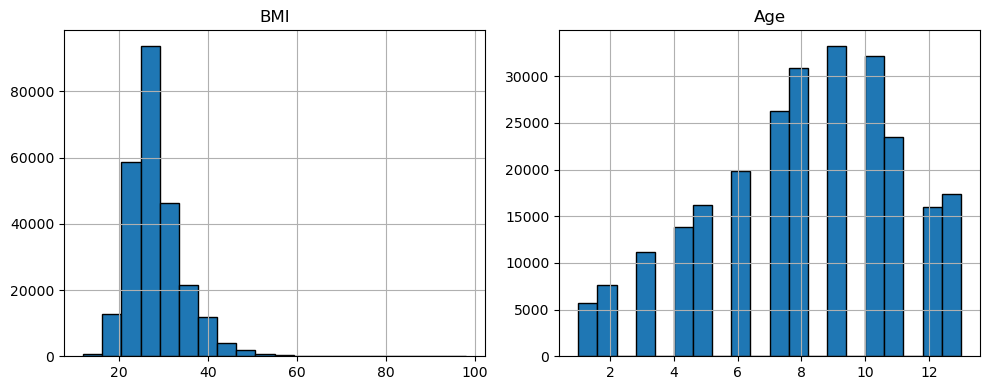

In [13]:
df[['BMI','Age']].hist(bins=20, edgecolor='black', figsize=(10,4))
plt.tight_layout()
plt.show()

In [14]:
#7.Korrelyasiya: BMI və PhysActivity arasında korrelyasiya hesabla; fiziki aktivlik BMI ilə necə bağlıdır? 

In [15]:
#8.Ehtimal hesabı: HighBP və HeartDiseaseorAttack üçün ehtimal tap; yüksək təzyiq və ürək xəstəliyi ehtimalı nədir? 

In [16]:
print(f'HighBP percentage: {(len(df['HighBP'][df['HighBP'] == 1]) / len(df['HighBP'])) * 100}%')
print(f'HeartDiseaseorAttack percentage: {(len(df['HeartDiseaseorAttack'][df['HeartDiseaseorAttack'] == 1]) / len(df['HeartDiseaseorAttack'])) * 100}%')

HighBP percentage: 42.90011037527594%
HeartDiseaseorAttack percentage: 9.418558814254178%


In [17]:
#9.Şərti ehtimal: Diabetes olan insanlar arasında HeartDiseaseorAttack ehtimalını hesablayın.  

In [33]:
print(f'HeartDiseaseorAttack percentage for Diabetes: {(len(df[(df['HeartDiseaseorAttack'] == 1) & (df['Diabetes'] == 1)]) / len(df[df['Diabetes'] == 1])) * 100}%')

HeartDiseaseorAttack percentage for Diabetes: 14.338155905851869%


In [19]:
#10.Outlier tapma: BMI üçün outlier-ləri boxplot ilə göstər; outlier-lər hansı diapazondadır? 

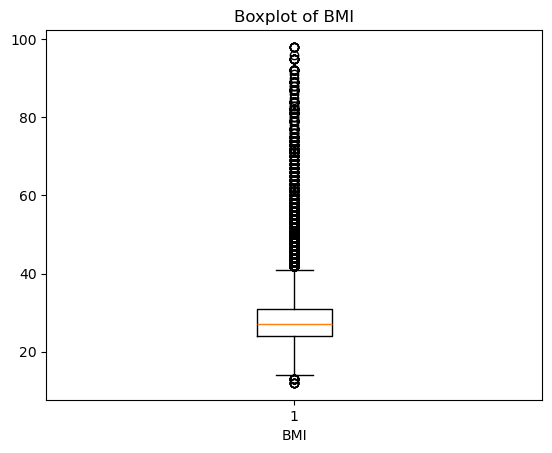

In [32]:
plt.boxplot(df['BMI'])
plt.title("Boxplot of BMI")
plt.xlabel("BMI")
plt.show()
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['BMI'] < lower_bound) | (df['BMI'] > upper_bound)]['BMI']